In [10]:
# Ran with predictors_simple kernel
# Python 3.10.8

import numpy as np # 1.26.4
import pandas as pd # 2.2.3
import tensorflow as tf # 2.10.0
import matplotlib # 3.10.3
import torch # 2.0.0

matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['font.sans-serif'] = 'Arial'

from matplotlib import pyplot as plt
from joblib import load
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import auc
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec
import seaborn as sns


import os

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction/Model")
from ADModel_act import ADModel_act
from Data import DataReader, SplitData, FastTensorDataLoader, one_hot_encode

os.chdir("/Users/claireleblanc/Documents/tools_software/adhunter")
from actpred.models import ActCNNSystem

# Set Numpy to display floats with 3 decimal places
np.set_printoptions(formatter={'float': lambda x: "{0:0.3f}".format(x)})

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction")

In [9]:
paddle_preds = pd.read_csv("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction/Data/tile_data_wrangled_53mer_Paddle_dask_preds.csv", 
                           index_col=0, 
                           converters={'paddle_centers' : pd.eval, 'paddle_preds' : pd.eval})

paddle_preds['40_tiles'] = paddle_preds['sequence'].str[-40:]

In [11]:
# Running ADHunter on the test data
adhunter_kernel_size = 5
dilation = 3 
hidden = 64

# Loading the ADHunter-GFP model
gfp_model = ActCNNSystem(hidden, adhunter_kernel_size, dilation, num_res_blocks=3)
gfp_model.load_state_dict(torch.load("../../../tools_software/adhunter/adhunter_gfp_v2.pt"))
gfp_model.eval()

sc_gfp=load('../../../tools_software/adhunter/scaler_gfp_v2.pkl')

# Used to encode the input sequence
alphabet="ACDEFGHIKLMNPQRSTVWY"
aa_to_i = {aa:i for i, aa in enumerate(alphabet)}
i_to_aa = {i:aa for i, aa in enumerate(alphabet)}

def run_adhunter(model, sequence, sc):
    """
    Runs ADHunter on an input sequence
    """
    X = np.asarray([[aa_to_i[aa] for aa in sequence]])
    X = torch.tensor(X)
    result = model(X)
    result = sc.inverse_transform(result.detach().numpy().reshape(-1, 1))
    return result[0,0]


# Predict ADHunter score for each 40aa tile in the test data set (other tiles are also part of the test data)
paddle_preds["adhunter_gfp_pred"] = [run_adhunter(gfp_model, tile, sc_gfp) for tile in paddle_preds["40_tiles"]]


/Users/claireleblanc/miniconda3/envs/predictors_simple/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `SpearmanCorrcoef` will save all targets and predictions in the buffer. For large datasets, this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


In [13]:
# Running ADHunter on the test data
adhunter_kernel_size = 5
dilation = 3 
hidden = 64

# Loading the ADHunter-GFP model
ratio_model = ActCNNSystem(hidden, adhunter_kernel_size, dilation, num_res_blocks=3)
ratio_model.load_state_dict(torch.load("/Users/claireleblanc/Documents/grad_school/staller_lab/Jack_stuff/staller-rotation/adhunter/adhunter.pt"))
ratio_model.eval()

sc_ratio=load('../../../tools_software/adhunter/scaler.pkl')

# Predict ADHunter score for each 40aa tile in the test data set (other tiles are also part of the test data)
paddle_preds["adhunter_ratio_pred"] = [run_adhunter(ratio_model, tile, sc_ratio) for tile in paddle_preds["40_tiles"]]


/Users/claireleblanc/miniconda3/envs/predictors_simple/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.2.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


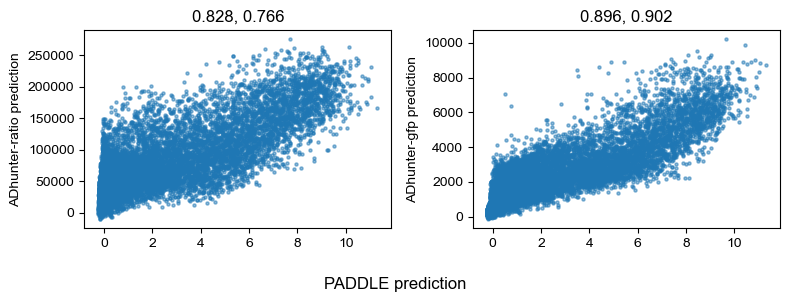

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3))

axs[0].scatter([ls[0] for ls in paddle_preds['paddle_preds']], paddle_preds['adhunter_ratio_pred'], s=5, alpha=0.5)
pearson = pearsonr([ls[0] for ls in paddle_preds['paddle_preds']], paddle_preds['adhunter_ratio_pred']).correlation
spearman = spearmanr([ls[0] for ls in paddle_preds['paddle_preds']], paddle_preds['adhunter_ratio_pred']).correlation
axs[0].set_title(f"{pearson:.3f}, {spearman:.3f}")
axs[0].set_ylabel("ADhunter-ratio prediction")

axs[1].scatter([ls[0] for ls in paddle_preds['paddle_preds']], paddle_preds['adhunter_gfp_pred'], s=5, alpha=0.5)
pearson = pearsonr([ls[0] for ls in paddle_preds['paddle_preds']], paddle_preds['adhunter_gfp_pred']).correlation
spearman = spearmanr([ls[0] for ls in paddle_preds['paddle_preds']], paddle_preds['adhunter_gfp_pred']).correlation
axs[1].set_title(f"{pearson:.3f}, {spearman:.3f}")
axs[1].set_ylabel("ADhunter-gfp prediction")

fig.supxlabel("PADDLE prediction")
fig.tight_layout()

In [18]:
pearsonr([ls[0] for ls in paddle_preds['paddle_preds']], paddle_preds['adhunter_gfp_pred'])

PearsonRResult(statistic=0.8958273779905712, pvalue=0.0)

In [19]:
pearsonr([ls[0] for ls in paddle_preds['paddle_preds']], paddle_preds['adhunter_ratio_pred'])

PearsonRResult(statistic=0.8275654718605987, pvalue=0.0)

In [35]:
tile_data = pd.read_csv("Data/pm_gcn4_sort2_pools_allchannels_wrangled.csv")


In [38]:
merged_data = tile_data.merge(paddle_preds, left_on='aa_seq', right_on='40_tiles')

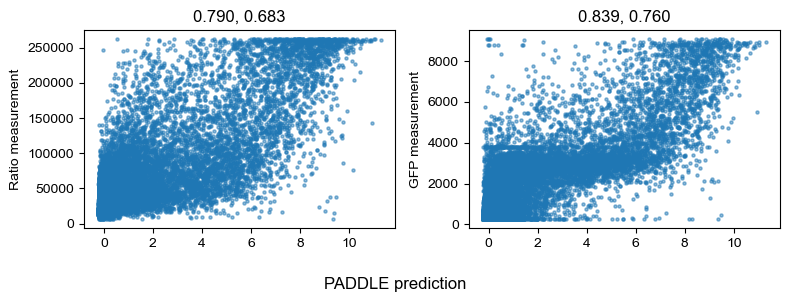

In [41]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3))

axs[0].scatter([ls[0] for ls in merged_data['paddle_preds']], merged_data['ratio'], s=5, alpha=0.5)
pearson = pearsonr([ls[0] for ls in merged_data['paddle_preds']], merged_data['ratio']).correlation
spearman = spearmanr([ls[0] for ls in merged_data['paddle_preds']], merged_data['ratio']).correlation
axs[0].set_title(f"{pearson:.3f}, {spearman:.3f}")
axs[0].set_ylabel("Ratio measurement")

axs[1].scatter([ls[0] for ls in merged_data['paddle_preds']], merged_data['activity'], s=5, alpha=0.5)
pearson = pearsonr([ls[0] for ls in merged_data['paddle_preds']], merged_data['activity']).correlation
spearman = spearmanr([ls[0] for ls in merged_data['paddle_preds']], merged_data['activity']).correlation
axs[1].set_title(f"{pearson:.3f}, {spearman:.3f}")
axs[1].set_ylabel("GFP measurement")

fig.supxlabel("PADDLE prediction")
fig.tight_layout()